# Stokes drag of a periodic array of cylinders

A square array of cylinders of radius $R$ (area fraction $c=\pi R^2$ in the unit cell) in slow viscous flow, driven by a uniform body force $f$ on the fluid. In steady state

* the force of the fluid on the cylinder balances the body force, $F = \rho f\,(1-c)$ per unit cell (momentum balance), and
* the drag coefficient $K = F/(\mu U)$, with $U$ the *superficial* velocity (the cell average, the solid counting zero), follows the Hasimoto / Sangani–Acrivos expansion
  $$K_{SA}(c)=\frac{4\pi}{-\tfrac12\ln c-0.738+c-0.887c^2+2.038c^3}$$
  for a pressure gradient acting on the whole cell; for a force acting on the fluid only the same flow carries the drag $(1-c)K_{SA}$ (the body force on the cylinder's area is missing).

This is the standard test of curved no-slip walls *with their loads*: the cylinder is a single exact analytic disk, its periodic images are shifted queries (no wall particles), and the load is read from
the solver. Both the flow (superficial velocity) and the load (momentum balance) are checked.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.scene.periodic import Periodic
from warpSPHBoundaries.scene.scene import Body, DiskArrayRep, Scene
from warpSPHBoundaries.sim.dfsph2d import carve, lattice_calibration, PACKING
from warpSPHBoundaries.sim.references import sangani_acrivos
from warpSPHBoundaries.sim.solvers import make_solver, lattice

n = {"quick": 32, "full": 48}[QUALITY]
radii = {"quick": [0.2], "full": [0.1, 0.2, 0.3]}[QUALITY]
nu, f, T = 0.0185, 0.03, {"quick": 30.0, "full": 40.0}[QUALITY]
dx = 1.0 / n

## One case

In [3]:
def run_array(R):
    pos = lattice((0, 0), (1, 1), dx)
    body = Body(bodyId=0, center=(0.5, 0.5), reps=[DiskArrayRep([(0.0, 0.0)], [R])])
    if SCHEME == "delta":
        pos = pos[np.linalg.norm(pos - 0.5, axis=1) >= R + 0.5 * dx]                 # the lattice cut at half a spacing from the cylinder
    else:
        cal = lattice_calibration(dx, dx, dx / PACKING)
        pos = carve(pos, [Body(bodyId=0, center=(0.5, 0.5), reps=[DiskArrayRep([(0.0, 0.0)], [R])])], dx / PACKING, cal["lamCell"], DEVICE)      # volume-consistent carving
    extra = {"maxDt": 1e-2} if SCHEME == "dfsph" else {}
    sol = make_solver(SCHEME, pos, dx, Scene([body], DEVICE), nu=nu, bodyForce=(f, 0.0), periodic=Periodic((0, 0), (1, 1)), c0=10 * f / (nu * 5), device=DEVICE, **extra)
    Fh, Uh = [], []
    def record(s):
        Fh.append(s.loads(0)[0]); Uh.append((s.time, float((s.v[:, 0] * s.volume).sum())))
    sol.run(T, every=T / 3, callback=record, report=lambda s: f"U = {Uh[-1][1]:.5f}  F = {np.mean(Fh[-50:]):.5f}")
    c = math.pi * R * R
    U = float((sol.v[:, 0] * sol.volume).sum())
    F = float(np.mean(Fh[-300:]))
    return dict(R=R, c=c, N=sol.n, U=U, F=F, Fbal=f * float(sol.volume.sum()), K=F / (nu * U), Kref=(1 - c) * sangani_acrivos(c), Uref=f / (nu * sangani_acrivos(c)), sol=sol, hist=Uh)

results = [run_array(R) for R in radii]

  t   10.000  dt 6.09e-03  vmax    0.121  U = 0.05087  F = 0.02524  [57 s]


  t   20.000  dt 6.09e-03  vmax    0.124  U = 0.05233  F = 0.02560  [119 s]


  t   30.001  dt 6.09e-03  vmax    0.125  U = 0.05233  F = 0.02556  [182 s]


## Comparison with the Sangani–Acrivos reference

scheme delta, n = 32
    R       c      N  F/balance  U/U_ref        K    K_ref  K/K_ref
 0.20  0.1257    876     1.0024   0.9777    26.45    26.49   0.9985


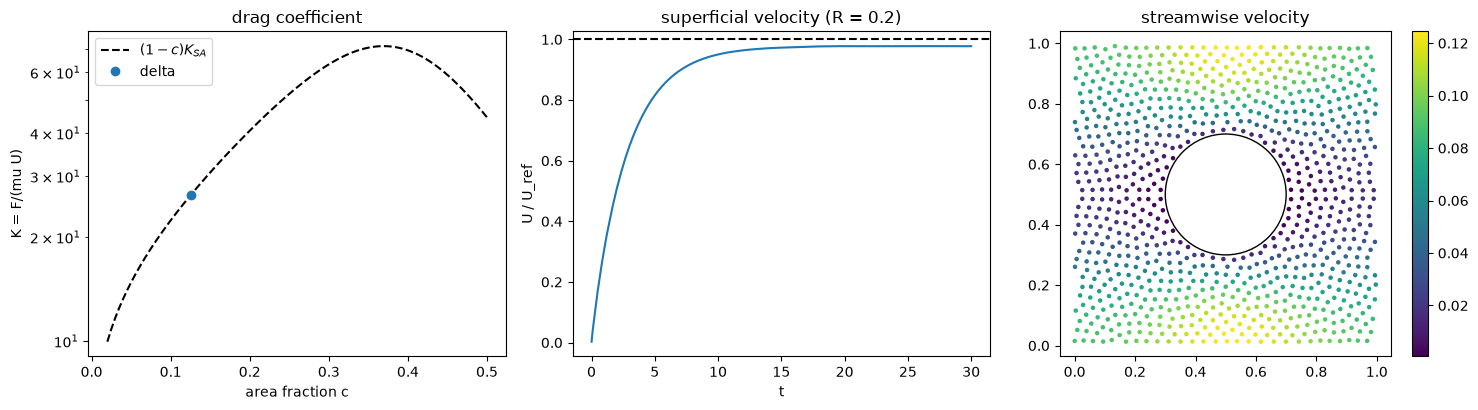

In [4]:
print(f"scheme {SCHEME}, n = {n}")
print(f"{'R':>5} {'c':>7} {'N':>6} {'F/balance':>10} {'U/U_ref':>8} {'K':>8} {'K_ref':>8} {'K/K_ref':>8}")
for r in results:
    print(f"{r['R']:5.2f} {r['c']:7.4f} {r['N']:6d} {r['F'] / r['Fbal']:10.4f} {r['U'] / r['Uref']:8.4f} {r['K']:8.2f} {r['Kref']:8.2f} {r['K'] / r['Kref']:8.4f}")

r0 = results[-1]
sol = r0["sol"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
cc = np.linspace(0.02, 0.5, 100)
ax[0].plot(cc, [(1 - c) * sangani_acrivos(c) for c in cc], "k--", label=r"$(1-c)K_{SA}$")
ax[0].plot([r["c"] for r in results], [r["K"] for r in results], "o", label=SCHEME); ax[0].set(xlabel="area fraction c", ylabel="K = F/(mu U)", yscale="log", title="drag coefficient"); ax[0].legend()
tt, U = zip(*r0["hist"]); ax[1].plot(tt, np.array(U) / r0["Uref"]); ax[1].axhline(1, color="k", ls="--"); ax[1].set(xlabel="t", ylabel="U / U_ref", title=f"superficial velocity (R = {r0['R']})")
q = ax[2].scatter(np.mod(sol.x[:, 0], 1), np.mod(sol.x[:, 1], 1), c=sol.v[:, 0], s=5); ax[2].add_patch(plt.Circle((0.5, 0.5), r0["R"], color="k", fill=False)); ax[2].set(aspect="equal", title="streamwise velocity"); plt.colorbar(q, ax=ax[2])
plt.tight_layout(); plt.show()

## What to look at

* `F/balance` is the momentum balance of the booked load: it should be 1 within a fraction of a per cent, independently of the wall model;
* `U/U_ref` and `K/K_ref` are the accuracy of the curved no-slip closure; the reference is a Stokes limit and the run has a small inertia, so a residual of a few per cent at this resolution is expected;
* the flow needs a few viscous times to reach the steady state (`F/balance` still below 1 means the run is not yet steady: lengthen `T`);
* `QUALITY = "full"` adds the solid fractions 0.03 and 0.28 (the lubrication-dominated, high-drag end is the hard one).